## **Install Library**

In [1]:
import shutil, os

CHROMA_DIR = "/content/chatbot-db/chroma_db"
GDRIVE_DIR = "/gdrive/MyDrive/chatbot-db/chroma_db"

if not os.path.exists(CHROMA_DIR) and os.path.exists(GDRIVE_DIR):
    os.makedirs(os.path.dirname(CHROMA_DIR), exist_ok=True)
    shutil.copytree(GDRIVE_DIR, CHROMA_DIR)
    print("Copied ChromaDB from GDrive")
else:
    print("ChromaDB already exists at", CHROMA_DIR)

ChromaDB already exists at /content/chatbot-db/chroma_db


In [2]:
!pip install -q transformers accelerate bitsandbytes gradio
!pip install -q langchain-text-splitters
!pip install -q langchain langchain-community chromadb pypdf sentence-transformers
!pip install -q huggingface_hub
!pip install -q fastapi uvicorn nest-asyncio
!pip install -q python-multipart

## **Cek GPU**

In [3]:
import torch

print("CUDA tersedia:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU aktif bang:", torch.cuda.get_device_name(0))
else:
    print("GPU tidak aktif. Aktifkan GPU bang")

CUDA tersedia: True
GPU aktif bang: Tesla T4


## **Import Library dan login Hugging Face**

In [4]:
import torch
import gradio as gr

from google.colab import files

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from google.colab import userdata
from huggingface_hub import login
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

HF_TOKEN = userdata.get("HF")
login(token=HF_TOKEN)

print("Login Hugging Face berhasil.")

/tmp/ipykernel_59672/1939175865.py:6: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


Login Hugging Face berhasil.


## **Menyimpan PDF permanen ke Gdrive**

In [5]:
from google.colab import drive
drive.mount('/gdrive', force_remount=True)

Mounted at /gdrive


## **Cek PDF di Gdrive**

In [6]:
import os

PDF_DIR = "/gdrive/MyDrive/chatbot-pdfs"

pdf_files = [
    os.path.join(PDF_DIR, f)
    for f in os.listdir(PDF_DIR)
    if f.lower().endswith(".pdf")
]

print(f"Jumlah PDF ditemukan: {len(pdf_files)}")

for pdf in pdf_files:
    print("-", os.path.basename(pdf))

Jumlah PDF ditemukan: 8
- Buku-Panduan-GenAI-Untuk-Mahasiswa-Bahasa-Indonesia.pdf
- pythonlearn.pdf
- progit.pdf
- Pemrograman Komputer FULL.pdf
- Pemrograman Web Dasar.pdf
- MySQLNotesForProfessionals.pdf
- 03. DASAR-DASAR PEMROGRAMAN.pdf
- 642863-dasar-dasar-coding-konsep-logika-dan-imp-bc07ac3d.pdf


## **Load isi PDF dan Filter halaman yang punya teks**

In [7]:
all_documents = []

for pdf_path in pdf_files:
    print(f"Loading {os.path.basename(pdf_path)}")

    loader = PyPDFLoader(pdf_path)
    docs = loader.load()

    all_documents.extend(docs)

documents = all_documents

documents_clean = []

for doc in documents:
    if doc.page_content.strip():
        documents_clean.append(doc)

print("Jumlah halaman asli:", len(documents))
print("Jumlah halaman berisi teks:", len(documents_clean))

print("Contoh isi dokumen bersih:")
print(documents_clean[0].page_content[:500])

Loading Buku-Panduan-GenAI-Untuk-Mahasiswa-Bahasa-Indonesia.pdf
Loading pythonlearn.pdf
Loading progit.pdf
Loading Pemrograman Komputer FULL.pdf
Loading Pemrograman Web Dasar.pdf
Loading MySQLNotesForProfessionals.pdf
Loading 03. DASAR-DASAR PEMROGRAMAN.pdf
Loading 642863-dasar-dasar-coding-konsep-logika-dan-imp-bc07ac3d.pdf
Jumlah halaman asli: 1456
Jumlah halaman berisi teks: 1449
Contoh isi dokumen bersih:
1
Kata Pengantar
Di era digital ini, teknologi terus berkembang dan menghadirkan berbagai ino -
vasi yang dapat mendukung pembelajaran, salah satunya adalah Genera -
tive AI (GenAI). Teknologi ini membuka peluang baru bagi mahasiswa un -
tuk belajar dengan cara yang lebih interaktif, kreatif, dan menyenangkan.
Bayangkan memiliki asisten virtual yang siap membantu kapan saja, mem -
bantu menjelaskan konsep sulit, merangkum materi kuliah, atau bah -
kan memberikan ide-ide kreatif untuk proyek akad


## **Chungking Dokumen**

In [8]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=700,
    chunk_overlap=150
)

chunks = text_splitter.split_documents(documents_clean)

print("Jumlah chunk:", len(chunks))
print("Contoh chunk:")
print(chunks[0].page_content[:500])

Jumlah chunk: 4225
Contoh chunk:
1
Kata Pengantar
Di era digital ini, teknologi terus berkembang dan menghadirkan berbagai ino -
vasi yang dapat mendukung pembelajaran, salah satunya adalah Genera -
tive AI (GenAI). Teknologi ini membuka peluang baru bagi mahasiswa un -
tuk belajar dengan cara yang lebih interaktif, kreatif, dan menyenangkan.
Bayangkan memiliki asisten virtual yang siap membantu kapan saja, mem -
bantu menjelaskan konsep sulit, merangkum materi kuliah, atau bah -
kan memberikan ide-ide kreatif untuk proyek akad


## **Embending**

In [9]:
EMBEDDING_MODEL = "BAAI/bge-m3"

embedding_model = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={
        "device": "cuda" if torch.cuda.is_available() else "cpu"
    },
    encode_kwargs={
        "normalize_embeddings": True
    }
)

print("Embedding model siap:", EMBEDDING_MODEL)

/tmp/ipykernel_59672/3841709472.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Embedding model siap: BAAI/bge-m3


## **Menyimpan Hasil ke ChromaDB**

In [10]:
import os
import glob
import json
import threading

CHROMA_DIR = "/content/chatbot-db/chroma_db"
os.makedirs(CHROMA_DIR, exist_ok=True)

PDF_DIR = "/gdrive/MyDrive/chatbot-pdfs/"
os.makedirs(PDF_DIR, exist_ok=True)

vector_db_lock = threading.Lock()
inference_lock = threading.Lock()

MANIFEST_PATH = os.path.join(PDF_DIR, "_processed_manifest.json")

def load_manifest():
    if os.path.exists(MANIFEST_PATH):
        with open(MANIFEST_PATH, "r") as f:
            return set(json.load(f))
    return set()

def save_manifest(processed_set):
    with open(MANIFEST_PATH, "w") as f:
        json.dump(sorted(processed_set), f, indent=2)

processed_pdfs = load_manifest()

db_exists = os.path.exists(os.path.join(CHROMA_DIR, "chroma.sqlite3"))

vector_db = Chroma(
    embedding_function=embedding_model,
    persist_directory=CHROMA_DIR
)

if db_exists:
    print("ChromaDB loaded dari Google Drive (persisten).")
else:
    print("ChromaDB baru dibuat di Google Drive.")

all_pdfs_in_dir = glob.glob(os.path.join(PDF_DIR, "*.pdf"))
new_pdfs = [p for p in all_pdfs_in_dir if os.path.basename(p) not in processed_pdfs]

if not new_pdfs:
    print("Tidak ada PDF baru untuk diproses, semua sudah ada di ChromaDB.")
else:
    for pdf_path in new_pdfs:
        loader = PyPDFLoader(pdf_path)
        docs = loader.load()
        docs_clean = [d for d in docs if d.page_content.strip()]
        pdf_chunks = text_splitter.split_documents(docs_clean)

        with vector_db_lock:
            vector_db.add_documents(pdf_chunks)
            processed_pdfs.add(os.path.basename(pdf_path))

        print(f"  -> {os.path.basename(pdf_path)}: {len(pdf_chunks)} chunk ditambahkan")

    save_manifest(processed_pdfs)

retriever = vector_db.as_retriever(search_kwargs={"k": 15})
print("Retriever aktif. Total PDF tercatat di manifest:", len(processed_pdfs))

/tmp/ipykernel_59672/2124515908.py:31: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vector_db = Chroma(


ChromaDB loaded dari Google Drive (persisten).
Tidak ada PDF baru untuk diproses, semua sudah ada di ChromaDB.
Retriever aktif. Total PDF tercatat di manifest: 8


## **Mengambil data dari PDF/Dokumen**

In [11]:
from pathlib import Path

def get_pdf_context(query, source_filter=None):
    try:
        docs = retriever.invoke(query)

        if source_filter:
            filtered = [d for d in docs if source_filter in Path(d.metadata.get('source', '')).name]
            if filtered:
                docs = filtered

        if not docs:
            return "Tidak ada konteks PDF yang relevan ditemukan."

        context = "\n\n".join([
            f"[Dokumen: {Path(d.metadata.get('source', 'unknown')).name}] Halaman {d.metadata.get('page', '?')}:\n{d.page_content}"
            for d in docs
        ])

        return context

    except Exception as e:
        return f"Gagal mengambil konteks dari PDF: {str(e)}"


def detect_topic(query):
    text = query.lower()

    topic_map = {
        "dasar-dasar pemrograman": ["java", "tipe data primitif", "identifier", "class", "komentar", "statement", "blok", "modulo", "operator aritmetika", "operator logika", "operator kondisi"],
        "pythonlearn": ["instalasi python", "tipe data dasar", "penugasan", "perbandingan", "if elif else", "for", "while", "range", "list", "tuple", "dictionary", "function", "return", "exception", "try except", "file teks", "class", "object", "__init__", "interpreter", "compiler", "variable name", "string slicing", "regular expression", "findall"],
        "progit": ["git", "snapshot", "vcs", "subversion", "svn", "commit", "branch", "merge conflict", "fetch", "pull", "rebase", "tag", "annotated tag", "github flow", "pull request", "stash", "bisect"],
        "mysqlnotes": ["mysql", "create database", "char", "varchar", "text", "distinct", "like", "wildcard", "join", "left join", "right join", "on duplicate key", "user-defined variable", "index", "foreign key", "error 1215", "date range"],
        "pemrograman web dasar": ["html", "css", "javascript", "php", "client side", "server side", "tabel html", "include", "require", "layout website"],
        "buku-panduan-genai": ["genai", "generative ai", "artificial intelligence", "tuce", "t.u.c.e.", "refleksi kritis", "bobot toleransi", "plagiarisme", "sanksi"],
        "pemrograman komputer full": ["return", "tanpa return", "__init__", "modul", "package", "import", "mode r", "mode w", "mode a", "variabel global", "variabel lokal"]
    }

    for topic, keywords in topic_map.items():
        for kw in keywords:
            if kw in text:
                return topic

    return None

In [12]:
print("=" * 60)
print("ISI PER PDF (dari ChromaDB)")
print("=" * 60)

all_docs = vector_db.get()
sources = {}
for doc_id, meta in zip(all_docs["ids"], all_docs["metadatas"]):
    src = os.path.basename(meta.get("source", "unknown"))
    if src not in sources:
        sources[src] = {"chunks": 0, "pages": set()}
    sources[src]["chunks"] += 1
    sources[src]["pages"].add(meta.get("page", "?"))

for pdf_name in sorted(processed_pdfs):
    info = sources.get(pdf_name, {"chunks": 0, "pages": set()})
    print(f" -  {pdf_name}: {info['chunks']} chunk dari {len(info['pages'])} halaman")

ISI PER PDF (dari ChromaDB)
 -  03. DASAR-DASAR PEMROGRAMAN.pdf: 0 chunk dari 0 halaman
 -  642863-dasar-dasar-coding-konsep-logika-dan-imp-bc07ac3d.pdf: 0 chunk dari 0 halaman
 -  Buku-Panduan-GenAI-Untuk-Mahasiswa-Bahasa-Indonesia.pdf: 0 chunk dari 0 halaman
 -  MySQLNotesForProfessionals.pdf: 0 chunk dari 0 halaman
 -  Pemrograman Komputer FULL.pdf: 0 chunk dari 0 halaman
 -  Pemrograman Web Dasar.pdf: 0 chunk dari 0 halaman
 -  progit.pdf: 0 chunk dari 0 halaman
 -  pythonlearn.pdf: 0 chunk dari 0 halaman


## **Sistem Prompt**

In [13]:
SYSTEM_PROMPT = """
Kamu adalah chatbot Generative AI sederhana berbasis NLP.

Tugas utama:
1. Menjawab pertanyaan umum dengan bahasa Indonesia yang jelas dan mudah dipahami.
2. Membantu coding ringan, terutama Python, HTML, CSS, JavaScript, dan error dasar.
3. Menjelaskan konsep programming untuk pemula.
4. Memberikan contoh kode sederhana jika dibutuhkan.
5. Jika tidak yakin, katakan bahwa kamu tidak yakin.
6. Jangan mengarang fakta yang terlalu spesifik.

Aturan jawaban:
- Jawab dalam bahasa Indonesia.
- Jawaban harus singkat, jelas, dan langsung ke inti.
- Untuk pertanyaan coding, jelaskan penyebab masalah dan berikan solusi.
- Jika memberi kode, gunakan kode yang sederhana dan mudah dipahami.
- Jangan membuat jawaban terlalu panjang kalau tidak diminta.
"""

CUSTOM_KNOWLEDGE = """
Informasi tentang chatbot ini:
- Chatbot ini dibuat menggunakan Google Colab.
- Model AI dijalankan menggunakan Hugging Face Transformers.
- Backend dibuat menggunakan FastAPI.
- Frontend dibuat menggunakan React dan TailwindCSS.
- Backend Colab dihubungkan ke frontend lokal menggunakan Cloudflare Tunnel.
- Chatbot ini ditujukan untuk menjawab pertanyaan umum dan membantu coding ringan.
"""

RAG_SYSTEM_PROMPT = """
Kamu adalah chatbot RAG yang menjawab BERDASARKAN konteks PDF.

Aturan WAJIB:
1. Jawab HANYA berdasarkan konteks PDF yang diberikan.
2. Perhatikan label [Dokumen: ...] di setiap potongan konteks. Jawab SESUAI dokumen yang relevan dengan pertanyaan.
3. JANGAN gunakan informasi dari dokumen yang tidak relevan dengan pertanyaan.
4. JANGAN campur informasi dari dokumen berbeda dalam satu jawaban.
5. Jika ada kontradiksi antar dokumen, utamakan yang sesuai topik pertanyaan.
6. Jika ditanya tentang isi dokumen tertentu, gunakan konteks PDF yang sudah diberikan.
7. Jika konteks cukup, jawab dengan jelas dan langsung.
8. Jika konteks tidak cukup, akui: "Dari dokumen yang tersedia, saya tidak menemukan informasi tentang..."
9. Jawab dalam bahasa Indonesia dengan jelas.
"""

mengtes spek colep buat model

In [14]:
!nvidia-smi

Sat Jun 27 03:54:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P0             26W /   70W |    2291MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## **Load Model General Knowlage**

In [15]:
MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    token=HF_TOKEN
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    token=HF_TOKEN,
    device_map="auto",
    quantization_config=bnb_config
)

model.eval()

print("Model berhasil diload.")

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Model berhasil diload.


## **Fungsi Untuk Generate Jawaban**

In [16]:
def build_rag_messages(user_message, history):
    intent = detect_intent(user_message)
    topic = detect_topic(user_message)

    pdf_context = get_pdf_context(user_message, source_filter=topic)
    daftar_pdf = "\n".join(f"- {p}" for p in sorted(processed_pdfs))
    pdf_context += f"\n\nDaftar dokumen yang tersedia:\n{daftar_pdf}"

    intent_instruction = f"""
Intent pengguna terdeteksi: {intent}
Topik terdeteksi: {topic or 'umum'}

Gunakan intent ini untuk membantu menjawab:
- coding_error: jelaskan penyebab error dan solusi
- coding_help: bantu dengan contoh kode sederhana
- general_question: jawab konsep umum dengan jelas
- general_chat: jawab secara natural
"""

    messages = [
        {
            "role": "system",
            "content": (
                "Konteks dari PDF:\n" + pdf_context
                + "\n\n"
                + RAG_SYSTEM_PROMPT
                + "\n\n"
                + CUSTOM_KNOWLEDGE
                + "\n\n"
                + intent_instruction
            )
        }
    ]

    for chat in history:
        if chat["role"] in ["user", "assistant"]:
            messages.append({
                "role": chat["role"],
                "content": chat["content"]
            })

    messages.append({
        "role": "user",
        "content": user_message
    })

    return messages

In [17]:
def detect_intent(user_message):
    text = user_message.lower()
    if any(word in text for word in ["error", "bug", "syntax", "nameerror", "modulenotfound", "traceback"]):
        return "coding_error"
    elif any(word in text for word in ["python", "html", "css", "javascript", "kode", "function", "array", "variabel"]):
        return "coding_help"
    elif any(word in text for word in ["apa itu", "jelaskan", "pengertian", "definisi", "konsep"]):
        return "general_question"
    else:
        return "general_chat"


def generate_response_rag(user_message, history):
    messages = build_rag_messages(user_message, history)

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(model.device)

    with inference_lock:
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=350,
                do_sample=True,
                temperature=0.3,
                top_p=0.9,
                repetition_penalty=1.05,
                pad_token_id=tokenizer.eos_token_id
            )

    input_length = inputs["input_ids"].shape[-1]
    generated_tokens = outputs[0][input_length:]

    answer = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    )

    answer = answer.replace("<|im_end|>", "").strip()
    return answer

test


In [18]:
question = "Jelaskan isi utama dari dokumen GenAI untuk mahasiswa"

answer = generate_response_rag(
    question,
    history=[]
)

print(answer)

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Dari dokumen yang tersedia, saya tidak menemukan informasi tentang isi utama dari buku panduan GenAI untuk mahasiswa. Untuk mendapatkan informasi tersebut, Anda mungkin perlu melihat dokumen "Buku-Panduan-GenAI-Untuk-Mahasiswa-Bahasa-Indonesia.pdf" yang tersedia.


## **Buat Backend FastAPI**

In [19]:
import queue
import asyncio
from threading import Thread
from transformers import TextStreamer

class AsyncStreamer(TextStreamer):
    def __init__(self, tokenizer, skip_prompt=True, skip_special_tokens=True):
        super().__init__(tokenizer, skip_prompt=skip_prompt, skip_special_tokens=skip_special_tokens)
        self.token_queue = queue.Queue()
        self.generation_finished = False

    def on_finalized_text(self, text: str, stream_end: bool = False):
        if stream_end:
            self.token_queue.put(None)
            self.generation_finished = True
        elif text:
            self.token_queue.put(text)

    async def get_token(self):
        while True:
            try:
                token = self.token_queue.get_nowait()
                return token
            except queue.Empty:
                if self.generation_finished:
                    return None
                await asyncio.sleep(0.01)

In [20]:
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from typing import List, Literal
import nest_asyncio
import uvicorn
import threading
import aiofiles
import os
from fastapi import UploadFile, File
from starlette.responses import StreamingResponse
import asyncio

api_app = FastAPI()

api_app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=False,
    allow_methods=["*"],
    allow_headers=["*"],
)

class ChatMessage(BaseModel):
    role: Literal["user", "assistant"]
    content: str

class ChatRequest(BaseModel):
    message: str
    history: List[ChatMessage] = []

@api_app.get("/")
def home():
    return {
        "message": "FastAPI chatbot backend baru jalan."
    }

@api_app.get("/api/ping")
def ping():
    return {
        "status": "ok",
        "message": "Backend baru bisa diakses."
    }

@api_app.post("/api/chat")
def chat(request: ChatRequest):
    user_message = request.message.strip()

    if not user_message:
        return {
            "reply": "Pesannya kosong. Ketik sesuatu dulu."
        }

    try:
        history = [
            msg.model_dump() if hasattr(msg, "model_dump") else msg.dict()
            for msg in request.history
        ]

        answer = generate_response_rag(
            user_message,
            history=history
        )

        return {
            "reply": answer
        }

    except Exception as e:
        return {
            "reply": f"Terjadi error di backend: {str(e)}"
        }

MAX_PDF_SIZE_MB = 20
UPLOAD_DIR = PDF_DIR

@api_app.post("/api/chat/stream")
async def chat_stream(request: ChatRequest):
    user_message = request.message.strip()

    if not user_message:
        async def empty_error():
            yield f"data: {json.dumps({'error': 'Pesannya kosong. Ketik sesuatu dulu.'})}\n\n"
            yield "data: [DONE]\n\n"
        return StreamingResponse(empty_error(), media_type="text/event-stream")

    try:
        history_raw = [
            msg.model_dump() if hasattr(msg, "model_dump") else msg.dict()
            for msg in request.history
        ]

        messages = build_rag_messages(user_message, history_raw)

        prompt = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )

        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

        streamer = AsyncStreamer(
            tokenizer,
            skip_prompt=True,
            skip_special_tokens=True,
        )

        async def generate():
            def run_model():
                with inference_lock:
                    with torch.no_grad():
                        model.generate(
                            **inputs,
                            max_new_tokens=350,
                            do_sample=True,
                            temperature=0.3,
                            top_p=0.9,
                            repetition_penalty=1.05,
                            pad_token_id=tokenizer.eos_token_id,
                            streamer=streamer,
                        )

            loop = asyncio.get_event_loop()
            future = loop.run_in_executor(None, run_model)

            while True:
                token = await streamer.get_token()
                if token is None:
                    break
                yield f"data: {json.dumps({'token': token})}\n\n"

            await future
            yield "data: [DONE]\n\n"

        return StreamingResponse(generate(), media_type="text/event-stream")

    except Exception as e:
        async def error_stream():
            yield f"data: {json.dumps({'error': f'Terjadi error di backend: {str(e)}'})}\n\n"
            yield "data: [DONE]\n\n"
        return StreamingResponse(error_stream(), media_type="text/event-stream")

## **Menjakankan FastAPI di Google Colab**

In [21]:
nest_asyncio.apply()

def run_api_8010():
    uvicorn.run(
        api_app,
        host="0.0.0.0",
        port=8010
    )

thread = threading.Thread(target=run_api_8010)
thread.start()

print("FastAPI baru jalan di port 8010")

FastAPI baru jalan di port 8010


## **Mengambil URL API Colab**

In [22]:
from google.colab.output import eval_js

api_url = eval_js("google.colab.kernel.proxyPort(8010)")
print("API URL:", api_url)

INFO:     Started server process [59672]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8010 (Press CTRL+C to quit)


API URL: https://8010-gpu-t4-s-kkb-usw4a0-2dcefnawjq804-a.us-west4-0.prod.colab.dev


## **Test BE Colab**

In [23]:
import requests

res = requests.get("http://127.0.0.1:8010/api/ping")
print(res.status_code)
print(res.json())

INFO:     127.0.0.1:48342 - "GET /api/ping HTTP/1.1" 200 OK
200
{'status': 'ok', 'message': 'Backend baru bisa diakses.'}


In [24]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

In [25]:
import subprocess
import time
import re

process = subprocess.Popen(
    ["./cloudflared", "tunnel", "--url", "http://127.0.0.1:8010"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

public_url = None

for _ in range(60):
    line = process.stdout.readline()
    print(line, end="")

    match = re.search(r"https://[-a-zA-Z0-9.]+\.trycloudflare\.com", line)
    if match:
        public_url = match.group(0)
        break

    time.sleep(1)

print("\nPUBLIC URL:", public_url)

2026-06-27T03:55:11Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-06-27T03:55:11Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-06-27T03:55:15Z INF +--------------------------------------------------------------------------------------------+
2026-06-27T03:55:15Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-06-27T03:55:15Z INF |  https://enrolled-reviewer-educators-frames.trycloudfl

## **Test chat apakah sesuai dgn rag**

In [26]:
res = requests.post(
    "http://127.0.0.1:8010/api/chat",
    json={
        "message": "Jelaskan apa isi dari dokumen progit?",
        "history": []
    }
)

print(res.status_code)
print(res.json())

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


INFO:     127.0.0.1:48844 - "POST /api/chat HTTP/1.1" 200 OK
200
{'reply': 'Dari dokumen yang tersedia, saya tidak menemukan informasi tentang isi dokumen progit. Namun, biasanya dokumen progit (yang merujuk pada progit.pdf) mungkin berisi materi tentang Git, yaitu perantara pemrograman yang digunakan untuk mengelola versi dokumen dan repositori. Dokumen ini mungkin mencakup konsep dasar Git seperti membuat branch, melakukan pull request, merge commits, dan sebagainya. Untuk informasi spesifik, Anda mungkin perlu membaca dokumen tersebut secara langsung.'}


## **Test Via Notebook**

In [27]:
context = get_pdf_context("Apa isi dokumen Progit bab 1")

print(context[:1500])

Tidak ada konteks PDF yang relevan ditemukan.


## **Eval ROUGE**

In [28]:
!pip install -q rouge-score


[1/90] Mengevaluasi: Sebutkan 8 (delapan) tipe data primitif dalam bahasa pemrogr...
INFO:     127.0.0.1:39148 - "POST /api/chat HTTP/1.1" 200 OK

[2/90] Mengevaluasi: Apa yang dimaksud dengan tipe data boolean dan apa saja nila...
INFO:     127.0.0.1:42144 - "POST /api/chat HTTP/1.1" 200 OK

[3/90] Mengevaluasi: Bagaimana cara membedakan penulisan tipe data char dengan St...
INFO:     127.0.0.1:38236 - "POST /api/chat HTTP/1.1" 200 OK

[4/90] Mengevaluasi: Sebutkan 3 (tiga) contoh penamaan identifier yang benar dan ...
INFO:     127.0.0.1:49784 - "POST /api/chat HTTP/1.1" 200 OK

[5/90] Mengevaluasi: Apa aturan khusus untuk penamaan identifier pada sebuah clas...
INFO:     127.0.0.1:35678 - "POST /api/chat HTTP/1.1" 200 OK

[6/90] Mengevaluasi: Apa perbedaan antara komentar bergaya C++ (// ...) dan komen...
INFO:     127.0.0.1:55950 - "POST /api/chat HTTP/1.1" 200 OK

[7/90] Mengevaluasi: Apa yang dimaksud dengan statement dan blok dalam bahasa pem...
INFO:     127.0.0.1:42718 - "POS

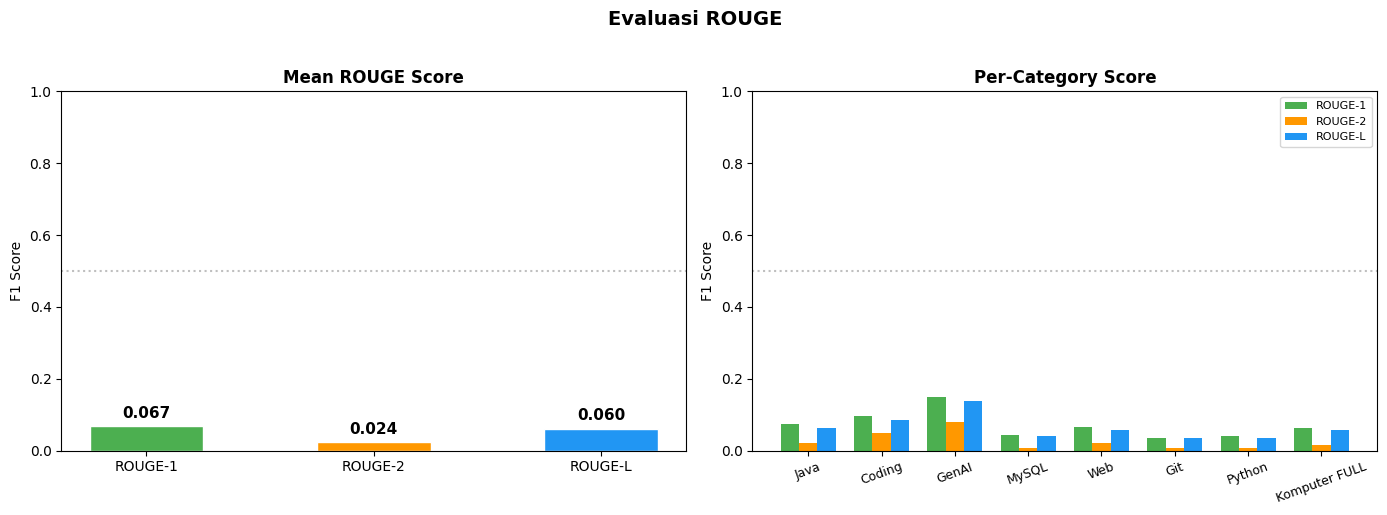


                    DETAIL HASIL

--- [Java] Q1: Sebutkan 8 (delapan) tipe data primitif dalam bahasa pemrograman Java! ---
  R1=0.110 | R2=0.028 | RL=0.082
  Ref: Halaman 4: Tipe Data Dasar/Primitif
  Ans: Dari dokumen yang tersedia, tidak ada informasi tentang tipe data primitif dalam bahasa pemrograman Java. Oleh karena itu, saya harus mengakui bahwa tidak dapat memberikan daftar tipe data primitif Java berdasarkan konteks yang diberikan.  [Dokumen: 03. DASAR-DASAR PEMROGRAMAN.pdf] [Dokumen: 642863-...

--- [Java] Q2: Apa yang dimaksud dengan tipe data boolean dan apa saja nilai yang dapat dihasilkannya? ---
  R1=0.150 | R2=0.077 | RL=0.150
  Ref: Halaman 5: Tipe data boolean (tipe data logika)
  Ans: Dari dokumen yang tersedia, saya tidak menemukan informasi spesifik tentang tipe data boolean dan nilai-nilai yang dapat dihasilkan. Namun, berdasarkan pengetahuan umum, saya bisa menjawab pertanyaan Anda:  Tipe data boolean adalah salah satu tipe data dasar dalam pemrograman yang han

In [ ]:
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt
import numpy as np
import requests

test_cases = [
    # Java (10) - 03. DASAR-DASAR PEMROGRAMAN.pdf
    {
        "question": "Sebutkan 8 (delapan) tipe data primitif dalam bahasa pemrograman Java!",
        "reference": "Halaman 4: Tipe Data Dasar/Primitif"
    },
    {
        "question": "Apa yang dimaksud dengan tipe data boolean dan apa saja nilai yang dapat dihasilkannya?",
        "reference": "Halaman 5: Tipe data boolean (tipe data logika)"
    },
    {
        "question": "Bagaimana cara membedakan penulisan tipe data char dengan String dalam kode Java?",
        "reference": "Halaman 10: String"
    },
    {
        "question": "Sebutkan 3 (tiga) contoh penamaan identifier yang benar dan 2 (dua) contoh yang salah beserta alasannya berdasarkan aturan umum penamaan di Java.",
        "reference": "Halaman 13: Java Identifier (Aturan penamaan bersifat umum)"
    },
    {
        "question": "Apa aturan khusus untuk penamaan identifier pada sebuah class di Java?",
        "reference": "Halaman 15: Aturan penamaan yang bersifat khusus - 1. Identifier class"
    },
    {
        "question": "Apa perbedaan antara komentar bergaya C++ (// ...) dan komentar bergaya C (/* ... */) dalam hal penggunaannya?",
        "reference": "Halaman 19: Komentar Dalam Bethesda Jave"
    },
    {
        "question": "Apa yang dimaksud dengan statement dan blok dalam bahasa pemrograman Java, dan bagaimana cara menuliskannya?",
        "reference": "Halaman 20: Statement dan Blok Dalam Bahasa Java"
    },
    {
        "question": "Jelaskan fungsi dari operator aritmetika '%' (modulo) beserta contoh penggunaannya.",
        "reference": "Halaman 23: Operator Aritmetika"
    },
    {
        "question": "Apa hasil dari operasi logika AND (&&) jika salah satu operandnya bernilai false?",
        "reference": "Halaman 26: Tabel Logika AND (&&)"
    },
    {
        "question": "Berdasarkan contoh di halaman 28, apa yang akan menjadi output dari program jika nilai siswa adalah 40 dan menggunakan operator kondisi (?:) dengan kondisi 'nilai>=70'?",
        "reference": "Halaman 28: Operator Kondisi (tanj) dan Tampilan Output"
    },
    # Coding (10) - 642863-dasar-dasar-coding-...pdf
    {
        "question": "Berdasarkan buku ini, apa yang dimaksud dengan coding dan mengapa penting untuk dipelajari di era digital?",
        "reference": "Bab 1 Halaman 1 dan Halaman 11: Pengertian Coding dan Pentingnya Belajar Coding"
    },
    {
        "question": "Jelaskan konsep dasar algoritma dan bagaimana hubungannya dengan coding!",
        "reference": "Bab 1 Halaman 3 dan Halaman 7: Konsep Dasar Algoritma dan Hubungan antara Coding dan Algoritma"
    },
    {
        "question": "Apa saja klasifikasi bahasa pemrograman yang dijelaskan dalam buku ini?",
        "reference": "Bab 2 Halaman 19: Klasifikasi Bahasa Pemrograman"
    },
    {
        "question": "Sebutkan tiga struktur dasar pemrograman yang dijelaskan dalam buku ini!",
        "reference": "Bab 3 Halaman 26: Konsep Dasar Pemrograman"
    },
    {
        "question": "Apa perbedaan utama antara perangkat input dan perangkat output, dan berikan contoh masing-masing!",
        "reference": "Bab 4 Halaman 42: Perangkat Input dan Output"
    },
    {
        "question": "Menurut buku ini, apa yang dimaksud dengan percabangan (branching) dan apa saja jenis-jenisnya?",
        "reference": "Bab 5 Halaman 49 dan Halaman 52: Pengertian Percabangan dan Jenis-Jenis Percabangan"
    },
    {
        "question": "Jelaskan pengertian perulangan (looping) dan sebutkan jenis-jenis perulangan yang umum digunakan!",
        "reference": "Bab 6 Halaman 63 dan Halaman 65: Mengenal Perulangan dan Jenis-jenis Perulangan"
    },
    {
        "question": "Apa yang dimaksud dengan array dan bagaimana array diimplementasikan dalam pemrograman?",
        "reference": "Bab 7 Halaman 73 dan Halaman 87: Pengertian Array dan Implementasi Array dalam Pemrograman"
    },
    {
        "question": "Apa manfaat utama dari penggunaan fungsi dalam pemrograman?",
        "reference": "Bab 8 Halaman 95: Manfaat Penggunaan Fungsi"
    },
    {
        "question": "Berdasarkan buku ini, apa yang dimaksud dengan rekursi dan jelaskan konsep dasarnya!",
        "reference": "Bab 9 Halaman 110: Konsep Dasar Rekursi"
    },
    # GenAI (10) - Buku-Panduan-GenAI-Untuk-Mahasiswa-...pdf
    {
        "question": "Jelaskan perbedaan utama antara Artificial Intelligence (AI) secara umum dan Generative AI (GenAI) berdasarkan aspek definisi dan fokus utama!",
        "reference": "Halaman 9-10: BAB 2 - 2.1. Perbedaan AI dan Generative AI (Tabel Perbandingan)"
    },
    {
        "question": "Sebutkan tiga jenis model Generative AI berdasarkan media yang dihasilkan beserta contoh aplikasinya!",
        "reference": "Halaman 12-13: BAB 2 - 2.3. Jenis-Jenis Generative AI"
    },
    {
        "question": "Apa saja yang dapat dan tidak dapat dilakukan oleh Generative AI? Sebutkan masing-masing tiga contoh!",
        "reference": "Halaman 13: BAB 2 - 2.5. Apa yang Generative AI Dapat Lakukan dan 2.6. Apa yang Generative AI Tidak Dapat Lakukan"
    },
    {
        "question": "Apa yang dimaksud dengan T.U.C.E. Framework dan jelaskan masing-masing tahapannya!",
        "reference": "Halaman 18: BAB 3 - 3.3. T.U.C.E. Framework (Think, Use, Check, Enhance)"
    },
    {
        "question": "Bagaimana cara yang benar untuk mencantumkan sumber atau atribusi jika menggunakan Generative AI dalam tugas akademik format karya tulis? Berikan satu contoh format sitasi!",
        "reference": "Halaman 19-20 dan 33: BAB 3 - 3.4. Tahapan Penggunaan Generative AI (poin 5 Source Citation and Attribution) dan BAB V - Tanya Jawab (poin 5)"
    },
    {
        "question": "Apa saja pertanyaan refleksi kritis yang harus dijawab mahasiswa sebelum memutuskan menggunakan Generative AI dalam tugas akademik?",
        "reference": "Halaman 16-17: BAB 3 - 3.2.1. Pertanyaan refleksi kritis yang perlu dijawab"
    },
    {
        "question": "Berapa bobot toleransi maksimal penggunaan Generative AI dalam kategori tugas Esai dan Makalah Akademik menurut panduan ini?",
        "reference": "Halaman 27: BAB 4 - 4.1.2. Bobot Toleransi Penggunaan Generative AI dalam Akademik (Tabel Skala Toleransi)"
    },
    {
        "question": "Sebutkan tiga jenis penyalahgunaan Generative AI dalam lingkungan akademik beserta penjelasannya!",
        "reference": "Halaman 30: BAB 4 - 4.3.1. Jenis Penyalahgunaan Generative AI"
    },
    {
        "question": "Apa saja sanksi yang dapat diberikan jika mahasiswa terbukti melakukan pelanggaran berat dalam penggunaan Generative AI?",
        "reference": "Halaman 30 dan 36: BAB 4 - 4.3.2. Sanksi Penyalahgunaan Generative AI dan BAB V - Tanya Jawab (poin 7)"
    },
    {
        "question": "Kapan mahasiswa tidak diperbolehkan menggunakan Generative AI dalam tugas akademik? Sebutkan dua kondisi!",
        "reference": "Halaman 32: BAB V - Tanya Jawab Seputar Penggunaan Generative AI Dalam Akademik (poin 2)"
    },
    # MySQL (10) - MySQLNotesForProfessionals.pdf
    {
        "question": "Bagaimana cara membuat database baru dan tabel baru di MySQL beserta contoh sintaks dasarnya?",
        "reference": "Halaman 11-12: Chapter 1 - Section 1.1: Getting Started (Creating a database, Creating a table, Inserting a row)"
    },
    {
        "question": "Sebutkan dan jelaskan perbedaan antara tipe data CHAR(n), VARCHAR, dan TEXT dalam MySQL!",
        "reference": "Halaman 7-8: Chapter 2 - Section 2.1: CHAR(n) dan Section 2.3: VARCHAR(255) - or not"
    },
    {
        "question": "Apa fungsi dari klausa DISTINCT dalam SELECT dan bagaimana cara penggunaannya?",
        "reference": "Halaman 12: Chapter 3 - Section 3.1: SELECT with DISTINCT"
    },
    {
        "question": "Jelaskan penggunaan operator LIKE dalam SELECT beserta contoh penggunaan wildcard '%' dan '_'!",
        "reference": "Halaman 13-14: Chapter 3 - Section 3.4: SELECT with LIKE (%)"
    },
    {
        "question": "Apa perbedaan antara JOIN, LEFT JOIN, dan RIGHT JOIN dalam MySQL? Berikan contoh visualisasi!",
        "reference": "Halaman 53: Chapter 16 - Section 16.1: Joins visualized"
    },
    {
        "question": "Bagaimana cara menggunakan INSERT dengan ON DUPLICATE KEY UPDATE untuk menangani data yang sudah ada?",
        "reference": "Halaman 32: Chapter 10 - Section 10.1: INSERT, ON DUPLICATE KEY UPDATE"
    },
    {
        "question": "Apa fungsi dari variabel user-defined dalam MySQL dan bagaimana cara menggunakannya?",
        "reference": "Halaman 28-29: Chapter 8 - Section 8.1: Setting Variables dan Section 8.2: Row Number and Group By"
    },
    {
        "question": "Jelaskan apa yang dimaksud dengan INDEX dalam MySQL dan bagaimana cara membuat index pada sebuah tabel!",
        "reference": "Halaman 102: Chapter 31 - Section 31.1: Create index dan Section 31.4: Create composite index"
    },
    {
        "question": "Apa penyebab dan solusi untuk Error 1215: Cannot add foreign key constraint dalam MySQL?",
        "reference": "Halaman 91-92: Chapter 29 - Section 29.3: Error code 1215: Cannot add foreign key constraint"
    },
    {
        "question": "Bagaimana cara menggunakan SELECT dengan date range yang benar agar dapat memanfaatkan indeks?",
        "reference": "Halaman 70: Chapter 21 - Section 21.5: Using an index for a date and time lookup"
    },
    # Web (10) - Pemrograman Web Dasar.pdf
    {
        "question": "Jelaskan apa yang dimaksud dengan HTML dan sebutkan fungsi-fungsi utamanya dalam membangun sebuah website!",
        "reference": "Bab 3 Halaman 19-21: Pengenalan HTML dan Fungsi HTML"
    },
    {
        "question": "Apa perbedaan antara Client Side Scripting dan Server Side Scripting? Berikan contoh masing-masing!",
        "reference": "Bab 1 Halaman 3-4: Pemrograman Web (Client Side Scripting dan Server Side Scripting)"
    },
    {
        "question": "Bagaimana cara membuat tabel di HTML dan sebutkan properti-properti penting yang digunakan dalam tag table!",
        "reference": "Bab 4 Halaman 37-39: Table (properti tabel dan contoh source code)"
    },
    {
        "question": "Jelaskan apa itu CSS dan bagaimana cara menyisipkan CSS ke dalam dokumen HTML (internal, eksternal, dan inline)!",
        "reference": "Bab 5 Halaman 51-56: Pengertian CSS, Fungsi CSS, dan Cara Penggunaan CSS (Internal, Eksternal, Inline)"
    },
    {
        "question": "Sebutkan tipe-tipe data variabel dalam JavaScript dan jelaskan operator perbandingan yang digunakan!",
        "reference": "Bab 6 Halaman 71-76: Variabel dan Operator (Aritmatika, Assignment, Pembanding, Logika)"
    },
    {
        "question": "Bagaimana cara menulis struktur percabangan (decision) IF-ELSE dalam PHP? Berikan contoh penggunaannya!",
        "reference": "Bab 8 Halaman 107-111: Decision IF (Bentuk umum dan contoh program)"
    },
    {
        "question": "Apa perbedaan antara fungsi include dan require dalam PHP dan kapan sebaiknya menggunakan masing-masing?",
        "reference": "Bab 8 Halaman 114-117: Include dan Require"
    },
    {
        "question": "Jelaskan apa yang dimaksud dengan MySQL dan sebutkan kelebihan serta kekurangan MySQL sebagai database management system!",
        "reference": "Bab 9 Halaman 121-124: Pengertian MySQL, Sejarah, Kelebihan dan Kekurangan MySQL"
    },
    {
        "question": "Bagaimana cara membuat koneksi database MySQL menggunakan PHP? Sebutkan fungsi-fungsi yang digunakan!",
        "reference": "Bab 10 Halaman 138-143: Merancang koneksi Database dan Penerapan PHP untuk Koneksi Database MySQL"
    },
    {
        "question": "Apa yang dimaksud dengan layout website dan sebutkan minimal 3 jenis layout yang umum digunakan!",
        "reference": "Bab 11 Halaman 153-156: Pengertian Layout Website dan Jenis-jenis Layout (Top Index, Bottom Index, Left Index, Layout Split, Alternating Index)"
    },
    # Git (10) - progit.pdf
    {
        "question": "Apa perbedaan mendasar antara cara Git menyimpan data dibandingkan dengan VCS lain seperti Subversion atau CVS?",
        "reference": "Chapter 1 - Getting Started (Halaman 14-15: Snapshots, Not Differences)"
    },
    {
        "question": "Jelaskan tiga status utama file dalam Git dan tiga bagian utama (working tree, staging area, dan Git directory) dalam proyek Git!",
        "reference": "Chapter 1 - Getting Started (Halaman 16-17: The Three States)"
    },
    {
        "question": "Bagaimana cara membuat branch baru dan beralih ke branch tersebut dalam satu perintah di Git?",
        "reference": "Chapter 3 - Git Branching (Halaman 70: Switching Branches, git checkout -b atau git switch -c)"
    },
    {
        "question": "Jelaskan apa yang dimaksud dengan merge conflict dan bagaimana cara menyelesaikannya di Git!",
        "reference": "Chapter 3 - Git Branching (Halaman 76-78: Basic Merge Conflicts)"
    },
    {
        "question": "Apa perbedaan antara git fetch dan git pull, dan kapan sebaiknya menggunakan masing-masing?",
        "reference": "Chapter 2 - Git Basics (Halaman 52-53: Fetching and Pulling from Your Remotes) dan Chapter 3 - Git Branching (Halaman 94: Pulling)"
    },
    {
        "question": "Apa yang dimaksud dengan rebasing dalam Git dan apa perbedaan utamanya dengan merging?",
        "reference": "Chapter 3 - Git Branching (Halaman 95-99: Rebasing dan Rebase vs. Merge)"
    },
    {
        "question": "Sebutkan dan jelaskan tiga jenis tag (tagging) dalam Git beserta perbedaannya!",
        "reference": "Chapter 2 - Git Basics (Halaman 55-57: Tagging, Annotated Tags, dan Lightweight Tags)"
    },
    {
        "question": "Jelaskan apa itu GitHub Flow dan bagaimana alur kerjanya dalam berkontribusi pada proyek open source!",
        "reference": "Chapter 6 - GitHub (Halaman 172-175: The GitHub Flow dan Creating a Pull Request)"
    },
    {
        "question": "Apa yang dimaksud dengan git stash dan bagaimana cara menggunakannya untuk menyimpan pekerjaan sementara?",
        "reference": "Chapter 7 - Git Tools (Halaman 230-234: Stashing and Cleaning, Stashing Your Work)"
    },
    {
        "question": "Jelaskan fungsi dari git bisect dan bagaimana cara menggunakannya untuk menemukan commit yang menyebabkan bug!",
        "reference": "Chapter 7 - Git Tools (Halaman 296-298: Binary Search, git bisect)"
    },
    # Pythonlearn (20) - pythonlearn.pdf
    {
        "question": "Jelaskan langkah-langkah instalasi Python dan bagaimana cara mencetak teks menggunakan fungsi print!",
        "reference": "Bab 1 Halaman 16-22 (Instalasi) dan Halaman 23-24 (Penggunaan print)"
    },
    {
        "question": "Sebutkan dan jelaskan minimal 5 tipe data dasar dalam Python beserta contohnya!",
        "reference": "Bab 2 Halaman 37-42 (Tipe Data)"
    },
    {
        "question": "Apa perbedaan antara operator '=' (penugasan) dan '==' (perbandingan) dalam Python? Berikan contoh!",
        "reference": "Bab 2 Halaman 43-45 (Operator Penugasan dan Perbandingan)"
    },
    {
        "question": "Bagaimana cara menulis struktur pemilihan kondisi if-elif-else di Python? Berikan contoh program konversi nilai!",
        "reference": "Bab 3 Halaman 56-64 (Pemilihan Kondisi, khususnya if elif else di halaman 63-64)"
    },
    {
        "question": "Jelaskan perbedaan antara perulangan for dan while di Python, serta berikan contoh penggunaan range dalam for!",
        "reference": "Bab 4 Halaman 67-75 (Pengulangan for, while, dan range)"
    },
    {
        "question": "Apa perbedaan antara tipe data list, tuple, dan dictionary? Berikan contoh cara mengakses, mengubah, dan menambahkan item pada masing-masing!",
        "reference": "Bab 5 Halaman 81-100 (List, Tuple, Dictionary) - terutama halaman 83-88 untuk perbedaan dan akses"
    },
    {
        "question": "Bagaimana cara mendefinisikan fungsi dengan parameter dan nilai balik (return) di Python? Berikan contoh fungsi untuk menghitung luas persegi panjang!",
        "reference": "Bab 6 Halaman 102-109 (Function dengan return dan parameter)"
    },
    {
        "question": "Apa yang dimaksud dengan exception dan bagaimana cara menangani error menggunakan try-except di Python?",
        "reference": "Bab 7 Halaman 121-140 (Exception dan try-except) - terutama halaman 123-126 untuk contoh"
    },
    {
        "question": "Bagaimana cara membaca dan menulis data ke file teks di Python? Sebutkan mode-mode yang umum digunakan beserta fungsinya!",
        "reference": "Bab 8 Halaman 141-156 - terutama halaman 142-148 untuk mode dan cara baca/tulis"
    },
    {
        "question": "Jelaskan konsep class dan object dalam Python, serta bagaimana cara membuat class dengan metode __init__!",
        "reference": "Bab 9 Halaman 157-166 - terutama halaman 159-162 untuk pembuatan class dan __init__"
    },
    {
        "question": "Apa perbedaan mendasar antara interpreter dan compiler dalam konteks eksekusi program Python?",
        "reference": "Chapter 1 - Why should you learn to write programs? (Halaman 8-9: Terminology: Interpreter and compiler)"
    },
    {
        "question": "Jelaskan aturan penamaan variabel yang benar dalam Python dan berikan contoh nama variabel yang valid dan tidak valid!",
        "reference": "Chapter 2 - Variables, expressions, and statements (Halaman 21: Variable names and keywords)"
    },
    {
        "question": "Bagaimana cara menangani error (exception) menggunakan try dan except dalam Python? Berikan contoh penggunaannya untuk menangani input numerik!",
        "reference": "Chapter 3 - Conditional execution (Halaman 36-38: Catching exceptions using try and except)"
    },
    {
        "question": "Apa yang dimaksud dengan fungsi (function) dalam Python dan bagaimana cara mendefinisikan fungsi dengan parameter dan nilai balik (return)?",
        "reference": "Chapter 4 - Functions (Halaman 47-52: Adding new functions, Parameters and arguments, Fruitful functions and void functions)"
    },
    {
        "question": "Jelaskan perbedaan antara perulangan while (indefinite loop) dan for (definite loop) beserta contoh penggunaannya!",
        "reference": "Chapter 5 - Iteration (Halaman 57-61: The while statement, Definite loops using for)"
    },
    {
        "question": "Apa itu string slicing dan bagaimana cara menggunakannya untuk mengambil sebagian dari sebuah string?",
        "reference": "Chapter 6 - Strings (Halaman 69: String slices)"
    },
    {
        "question": "Bagaimana cara membaca file teks baris per baris menggunakan Python dan mencari pola tertentu dalam setiap baris?",
        "reference": "Chapter 7 - Files (Halaman 82-85: Reading files, Searching through a file)"
    },
    {
        "question": "Apa perbedaan antara list dan tuple dalam Python, dan kapan sebaiknya menggunakan masing-masing?",
        "reference": "Chapter 8 - Lists (Halaman 92: Lists are mutable) dan Chapter 10 - Tuples (Halaman 119: Tuples are immutable, 126-127: Sequences: strings, lists, and tuples)"
    },
    {
        "question": "Bagaimana cara menggunakan dictionary untuk menghitung frekuensi kemunculan kata dalam sebuah file teks?",
        "reference": "Chapter 9 - Dictionaries (Halaman 111-113: Dictionary as a set of counters, Dictionaries and files)"
    },
    {
        "question": "Apa fungsi dari modul re (regular expression) dalam Python dan bagaimana cara mengekstrak data dari string menggunakan findall()?",
        "reference": "Chapter 11 - Regular expressions (Halaman 133-135: Extracting data using regular expressions)"
    },
    # Komputer FULL (10) - Pemrograman Komputer FULL.pdf
    {
        "question": "Apa perbedaan antara fungsi (function) yang menggunakan statemen 'return' dan yang tidak menggunakan 'return'? Berikan contoh masing-masing!",
        "reference": "Bab 6 Halaman 102-109 (Function dengan return dan tanpa return)"
    },
    {
        "question": "Jelaskan apa yang dimaksud dengan metode __init__ dalam pembuatan class di Python dan apa fungsinya!",
        "reference": "Bab 9 Halaman 159-162 (Penggunaan __init__ pada class)"
    },
    {
        "question": "Sebutkan 3 tipe data struktur (collection) dalam Python dan jelaskan perbedaan utama antara list, tuple, dan dictionary!",
        "reference": "Bab 5 Halaman 81-83 (List, Tuple, Dictionary) dan Bab 2 Halaman 38-40 (Tipe data)"
    },
    {
        "question": "Bagaimana cara menulis struktur pemilihan kondisi 'if-elif-else' yang benar di Python? Berikan contoh program konversi nilai!",
        "reference": "Bab 3 Halaman 62-64 (Kondisi if elif else) dan Bab 3 Halaman 63-64 (Contoh konversi nilai)"
    },
    {
        "question": "Apa yang dimaksud dengan modul (module) dan packages dalam Python, serta bagaimana cara mengimpor modul ke dalam program?",
        "reference": "Bab 10 Halaman 167-171 (Modul dan Packages) dan Halaman 171-172 (Import modul)"
    },
    {
        "question": "Jelaskan cara membaca dan menulis file teks di Python dengan menggunakan mode 'r', 'w', dan 'a'!",
        "reference": "Bab 8 Halaman 142-148 (Membaca file, Menulis data file, Menyisipkan data dengan mode 'a')"
    },
    {
        "question": "Apa fungsi dari blok 'try-except' dalam Python dan bagaimana cara menggunakannya untuk menangani error pada program?",
        "reference": "Bab 7 Halaman 123-126 (Exception dan try-except) dan Halaman 129-130 (Multiple except)"
    },
    {
        "question": "Jelaskan perbedaan penggunaan operator logika 'and' dan 'or' dalam Python beserta contohnya!",
        "reference": "Bab 2 Halaman 49-50 (Operator Logika - And, Or, Not)"
    },
    {
        "question": "Bagaimana cara mengimport modul yang telah dibuat sendiri (custom module) ke dalam program Python utama?",
        "reference": "Bab 10 Halaman 171-173 (Contoh penggunaan modul latihanModul) dan Halaman 180-181 (Membuat modul dalam direktori Python)"
    },
    {
        "question": "Apa yang dimaksud dengan variabel global dan lokal dalam Python, serta bagaimana cara mendeklarasikan variabel global di dalam fungsi?",
        "reference": "Bab 6 Halaman 111-112 (Scope Variabel - Local dan Global)"
    }
]

scorer = rouge_scorer.RougeScorer(
    ["rouge1", "rouge2", "rougeL"],
    use_stemmer=False  
)

results = []
for i, tc in enumerate(test_cases):
    print(f"\n[{i+1}/{len(test_cases)}] Mengevaluasi: {tc['question'][:60]}...")
    resp = requests.post(
        "http://127.0.0.1:8010/api/chat",
        json={"message": tc["question"], "history": []}
    )
    model_answer = resp.json()["reply"]
    scores = scorer.score(tc["reference"], model_answer)
    results.append({
        "question": tc["question"],
        "reference": tc["reference"],
        "model_answer": model_answer,
        "rouge1": scores["rouge1"].fmeasure,
        "rouge2": scores["rouge2"].fmeasure,
        "rougeL": scores["rougeL"].fmeasure,
    })

avg_r1 = np.mean([r["rouge1"] for r in results])
avg_r2 = np.mean([r["rouge2"] for r in results])
avg_rl = np.mean([r["rougeL"] for r in results])

# --- SUMMARY ---
print("\n" + "=" * 70)
print("                     ROUGE SCORES SUMMARY")
print("=" * 70)
print(f"  ROUGE-1 (unigram):      {avg_r1:.4f}")
print(f"  ROUGE-2 (bigram):       {avg_r2:.4f}")
print(f"  ROUGE-L (LCS):          {avg_rl:.4f}")
print("=" * 70)

# --- PER CATEGORY ---
categories = [
    ("Java", 0, 10), ("Coding", 10, 20), ("GenAI", 20, 30),
    ("MySQL", 30, 40), ("Web", 40, 50), ("Git", 50, 60),
    ("Python", 60, 80), ("Komputer FULL", 80, 90)
]
print("\n--- PER CATEGORY ---")
for name, start, end in categories:
    subset = results[start:end]
    r1 = np.mean([r["rouge1"] for r in subset])
    r2 = np.mean([r["rouge2"] for r in subset])
    rl = np.mean([r["rougeL"] for r in subset])
    print(f"  {name:15s}  R1={r1:.3f}  R2={r2:.3f}  RL={rl:.3f}")

# --- FIGURE 1: Bar charts only (no table) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Evaluasi ROUGE", fontsize=14, fontweight="bold", y=1.02)

# Left: mean scores
colors = ["#4CAF50", "#FF9800", "#2196F3"]
metrics = ["ROUGE-1", "ROUGE-2", "ROUGE-L"]
values = [avg_r1, avg_r2, avg_rl]
bars = ax1.bar(metrics, values, color=colors, width=0.5, edgecolor="white")
ax1.set_ylim(0, 1)
ax1.set_ylabel("F1 Score")
ax1.set_title("Mean ROUGE Score", fontweight="bold")
ax1.axhline(y=0.5, color="gray", linestyle=":", alpha=0.5)
for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
             f"{val:.3f}", ha="center", va="bottom", fontweight="bold", fontsize=11)

# Right: per-category
cat_names = [c[0] for c in categories]
cat_r1 = [np.mean([r["rouge1"] for r in results[s:e]]) for _, s, e in categories]
cat_r2 = [np.mean([r["rouge2"] for r in results[s:e]]) for _, s, e in categories]
cat_rl = [np.mean([r["rougeL"] for r in results[s:e]]) for _, s, e in categories]

x = np.arange(len(cat_names))
width = 0.25
ax2.bar(x - width, cat_r1, width, label="ROUGE-1", color="#4CAF50")
ax2.bar(x, cat_r2, width, label="ROUGE-2", color="#FF9800")
ax2.bar(x + width, cat_rl, width, label="ROUGE-L", color="#2196F3")
ax2.set_xticks(x)
ax2.set_xticklabels(cat_names, fontsize=9)
ax2.set_ylim(0, 1)
ax2.set_ylabel("F1 Score")
ax2.set_title("Per-Category Score", fontweight="bold")
ax2.legend(fontsize=8)
ax2.axhline(y=0.5, color="gray", linestyle=":", alpha=0.5)
ax2.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

# --- DETAIL PRINT ---
print("\n" + "=" * 70)
print("                    DETAIL HASIL")
print("=" * 70)
for i, r in enumerate(results, 1):
    cat = ""
    for name, s, e in categories:
        if s <= i-1 < e:
            cat = f"[{name}]"
            break
    print(f"\n--- {cat} Q{i}: {r['question']} ---")
    print(f"  R1={r['rouge1']:.3f} | R2={r['rouge2']:.3f} | RL={r['rougeL']:.3f}")
    print(f"  Ref: {r['reference']}")
    # preview answer 300 chars
    ans_preview = r['model_answer'][:300].replace("\n", " ")
    print(f"  Ans: {ans_preview}...")

## **Web Chatbot by Gradio**

In [30]:
demo = gr.ChatInterface(
    fn=generate_response_rag,
    type="messages",
    title="Chatbot",
    description="Chatbot Sederhana sesederhana anahredeS."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://599de487be3aa371b6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
